# Confidence Intervals for the Difference of Two Means  
## Practical Examples with Paired and Independent Samples

This notebook presents practical examples of how to compute **confidence intervals for the difference of two means** under different statistical assumptions.  
The examples are inspired by gameplay performance metrics from *Resident Evil 2* and *Resident Evil 7*, but all datasets are fictional and created for educational purposes.

---

## Objectives

- Understand when to use **paired (dependent) samples** vs **independent samples**  
- Learn how to build **confidence intervals for the difference of two means**  
- Apply the correct **formula** depending on:
  - Whether samples are dependent or independent  
  - Whether population variances are known or unknown  
  - Whether variances can be assumed equal  

---

## Scenarios Covered in This Notebook

### 1. Paired Samples (Dependent Samples)
**Example:**  
Stress level measured *before and after treatment* for the same individuals.

**When to use:**  
- The same subjects are measured twice  
- Observations are naturally paired (before/after, pre-test/post-test)

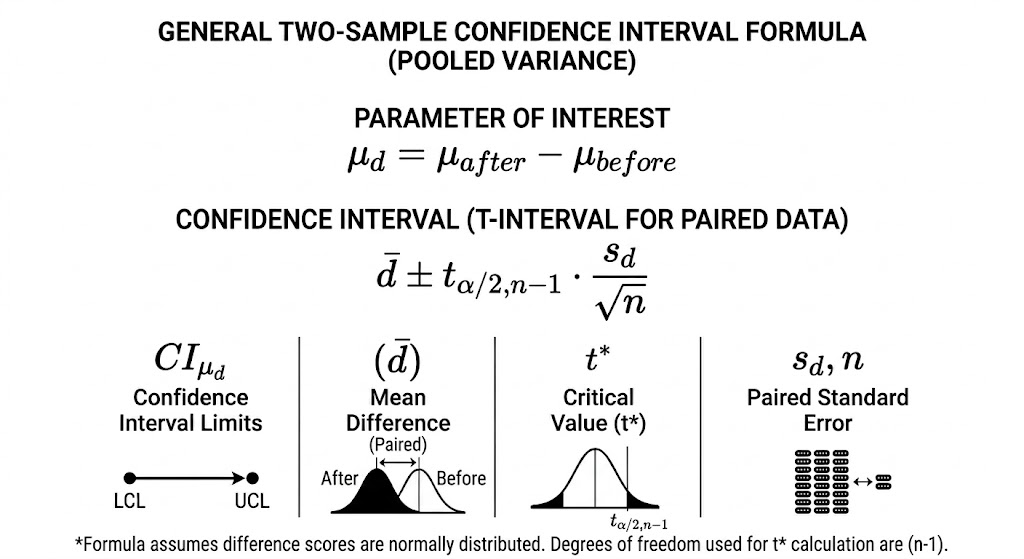


Where:
- \( \bar{d} \) = mean of the differences  
- \( s_d \) = standard deviation of the differences  
- \( n \) = number of paired observations  
- \( t_{\alpha/2, n-1} \) = critical value from the t distribution  

---

### 2. Independent Samples, Variances Known (Z-interval)
**Example:**  
Comparing body weight (kg) between two independent groups of survivors (infected vs non-infected).

**When to use:**  
- Groups are independent  
- Population variances are known (or assumed known from reliable external studies)  
- Sample sizes are moderate or large

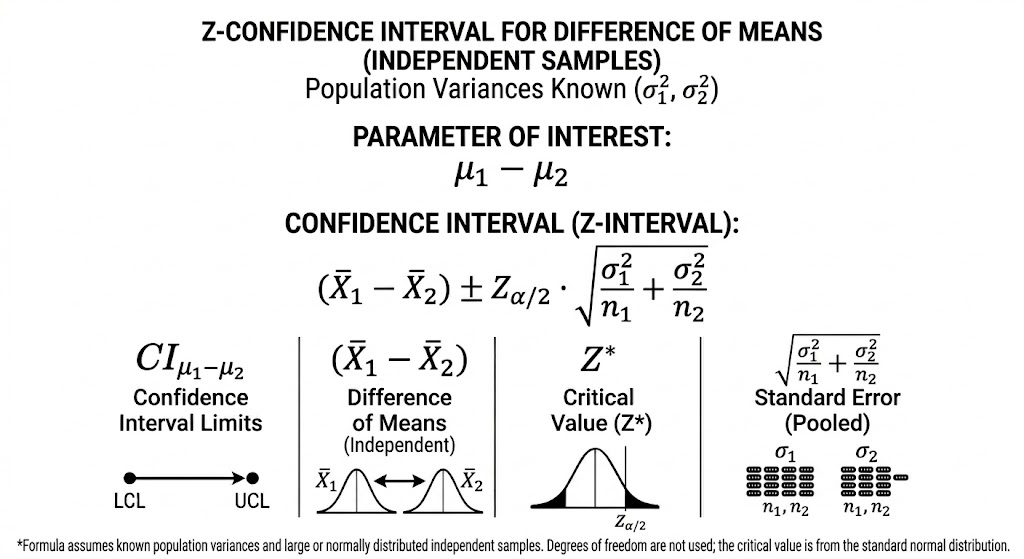

---

### 3. Independent Samples, Variances Unknown but Assumed Equal (Pooled t-interval)
**Example:**  
Comparing **boss fight duration (minutes)** between players in *Resident Evil 2* and *Resident Evil 7*.

**When to use:**  
- Groups are independent  
- Population variances are unknown  
- It is reasonable to assume equal variances  
- Sample sizes may be different

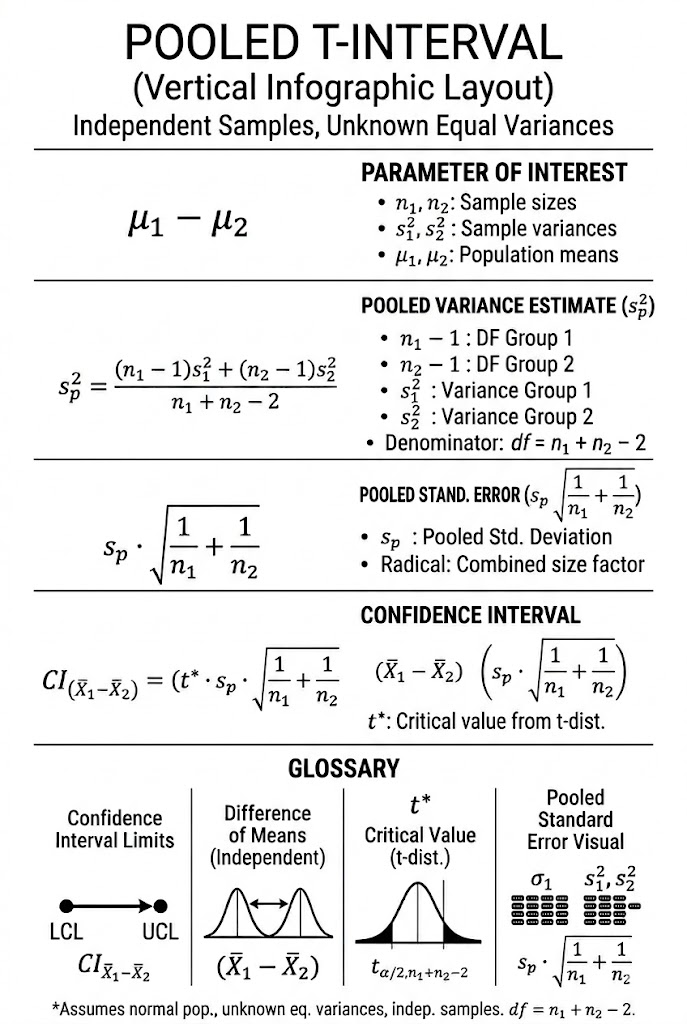
---

## How to Interpret the Confidence Intervals

- If the confidence interval **does not include 0**, there is evidence of a **statistically significant difference** between the two means.  
- If the confidence interval **includes 0**, the data do not provide enough evidence of a significant difference.  
- Higher confidence levels (e.g., 99%) produce **wider intervals**.  
- Lower confidence levels (e.g., 90%) produce **narrower intervals**.

---

## Summary: Which Method Should I Use?

| Scenario | Samples | Variances | Method |
|---------|---------|-----------|--------|
| Before vs After (same people) | Dependent | Unknown | Paired t-interval |
| Two independent groups, σ known | Independent | Known | Z-interval |
| Two independent groups, σ unknown but equal | Independent | Unknown (assumed equal) | Pooled t-interval |

---

This notebook demonstrates how choosing the correct confidence interval formula depends on the **data structure** and **assumptions** behind the experiment.

# **Confidence interval for difference of two means, dependent samples**

In [ ]:
# Intervalos de confiança
# Confidence interval for difference of two means, dependent samples
import pandas as pd

data = {
    "ID": [1,2,3,4,5,6,7,8,9,10],
    "Name": [
        "Leon Kennedy",
        "Claire Redfield",
        "Jill Valentine",
        "Chris Redfield",
        "Ada Wong",
        "Rebecca Chambers",
        "Albert Wesker",
        "Carlos Oliveira",
        "Sheva Alomar",
        "Ethan Winters"
    ],
    "Before_Treatment_Stress": [82, 75, 78, 85, 70, 68, 90, 73, 77, 88],
    "After_Treatment_Stress": [55, 48, 52, 60, 45, 40, 72, 50, 49, 63]
}

df = pd.DataFrame(data)
df["Difference_After_Minus_Before"] = df["After_Treatment_Stress"] - df["Before_Treatment_Stress"]

print(df)


   ID              Name  Before_Treatment_Stress  After_Treatment_Stress  \
0   1      Leon Kennedy                       82                      55   
1   2   Claire Redfield                       75                      48   
2   3    Jill Valentine                       78                      52   
3   4    Chris Redfield                       85                      60   
4   5          Ada Wong                       70                      45   
5   6  Rebecca Chambers                       68                      40   
6   7     Albert Wesker                       90                      72   
7   8   Carlos Oliveira                       73                      50   
8   9      Sheva Alomar                       77                      49   
9  10     Ethan Winters                       88                      63   

   Difference_After_Minus_Before  
0                            -27  
1                            -27  
2                            -26  
3                      

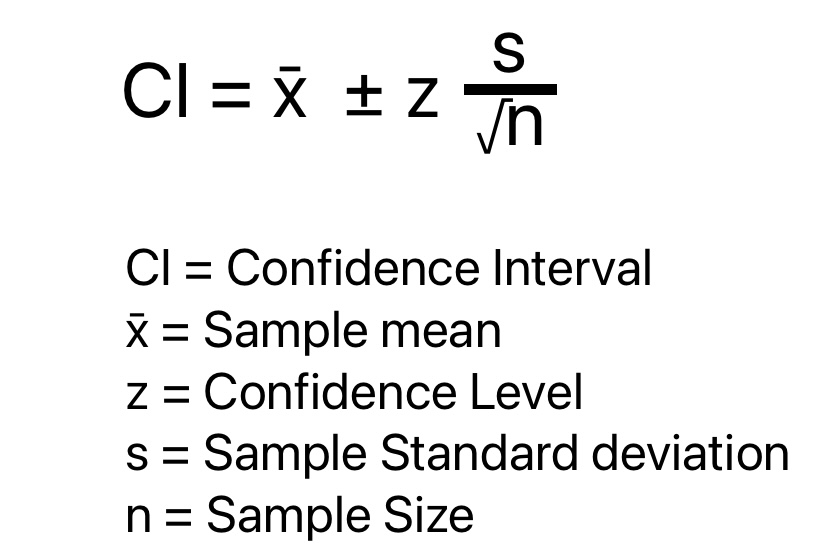

In [ ]:
import numpy as np

# Calculate the mean, standard deviation
difference_mean = df['Difference_After_Minus_Before'].mean()
difference_mean
# Appropriate statistic
# R: T-Statistic
# Interval Confidence with 95%

std_value = df['Difference_After_Minus_Before'].std()
print(std_value)
std_error = std_value / np.sqrt(df['ID'].count())
print(std_error)
# np.sqrt()

result_1 = round(difference_mean + (2.262 * (std_error/np.sqrt(df['ID'].count()))),2) # (95%, and 9 degrees of freedom, we must look in the T Table, considering alpha 0.025, the value I found it was 2.26)
result_2 = round(difference_mean - (2.262 * (std_error/np.sqrt(df['ID'].count()))),2)

print('95%')
print(f'The confidence interval that represents the difference between before and after stress treatment was in ({result_2},{result_1})')
# Interpretation
print('You are 95% confident that you will decrease between -25 and -26 levels of stress, given that you follow the treatment')

# Do with to 90% and 99%
# 90%
print('90%')
result_11 = round(difference_mean + (3.24 * (std_error/np.sqrt(df['ID'].count()))),2) # (90%, and 9 degrees of freedom, we must look in the T Table, considering alpha 0,01/2 -> 0.005, the value I found it was 3.24)
result_22 = round(difference_mean - (3.24 * (std_error/np.sqrt(df['ID'].count()))),2)
print(f'The confidence interval that represents the difference between before and after stress treatment was in ({result_22},{result_11})')

# 99%
print('99%')
result_111 = round(difference_mean + (4.78 * (std_error/np.sqrt(df['ID'].count()))),2) # (99%, and 9 degrees of freedom, we must look in the T Table, considering alpha 0,001/2 -> 0.0005, the value I found it was 4.78)
result_222 = round(difference_mean - (4.78 * (std_error/np.sqrt(df['ID'].count()))),2)
print(f'The confidence interval that represents the difference between before and after stress treatment was in ({result_222},{result_111})')

2.973961069759395
0.9404490653110589
95%
The confidence interval that represents the difference between before and after stress treatment was in (-25.87,-24.53)
You are 95% confident that you will decrease between -25 and -26 levels of stress, given that you follow the treatment
90%
The confidence interval that represents the difference between before and after stress treatment was in (-26.16,-24.24)
99%
The confidence interval that represents the difference between before and after stress treatment was in (-26.62,-23.78)


# **Confidence interval for the difference of two means. Independent samples, variance known**

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_A = 100  # Infected
n_B = 100  # Non-Infected

mu_A, sigma_A = 70.0, 4.0   # kg
mu_B, sigma_B = 75.0, 5.0   # kg


weights_A = np.random.normal(mu_A, sigma_A, n_A).round(1)
weights_B = np.random.normal(mu_B, sigma_B, n_B).round(1)

df_A = pd.DataFrame({
    "ID": range(1, n_A + 1),
    "Group": "Infected",
    "Body_Weight_kg": weights_A
})

df_B = pd.DataFrame({
    "ID": range(n_A + 1, n_A + n_B + 1),
    "Group": "Non-Infected",
    "Body_Weight_kg": weights_B
})

df = pd.concat([df_A, df_B], ignore_index=True)


group_means = df.groupby("Group")["Body_Weight_kg"].mean()
mean_A = group_means["Infected"]
mean_B = group_means["Non-Infected"]

df["GroupA_Mean"] = mean_A
df["GroupB_Mean"] = mean_B

df_2 = df

In [ ]:
df_2.shape

(200, 5)

In [ ]:
df

,ID,Group,Body_Weight_kg,GroupA_Mean,GroupB_Mean
0,1,Infected,72.0,69.585,75.113
1,2,Infected,69.4,69.585,75.113
2,3,Infected,72.6,69.585,75.113
3,4,Infected,76.1,69.585,75.113
4,5,Infected,69.1,69.585,75.113
...,...,...,...,...,...
195,196,Non-Infected,76.9,69.585,75.113
196,197,Non-Infected,70.6,69.585,75.113
197,198,Non-Infected,75.8,69.585,75.113
198,199,Non-Infected,75.3,69.585,75.113


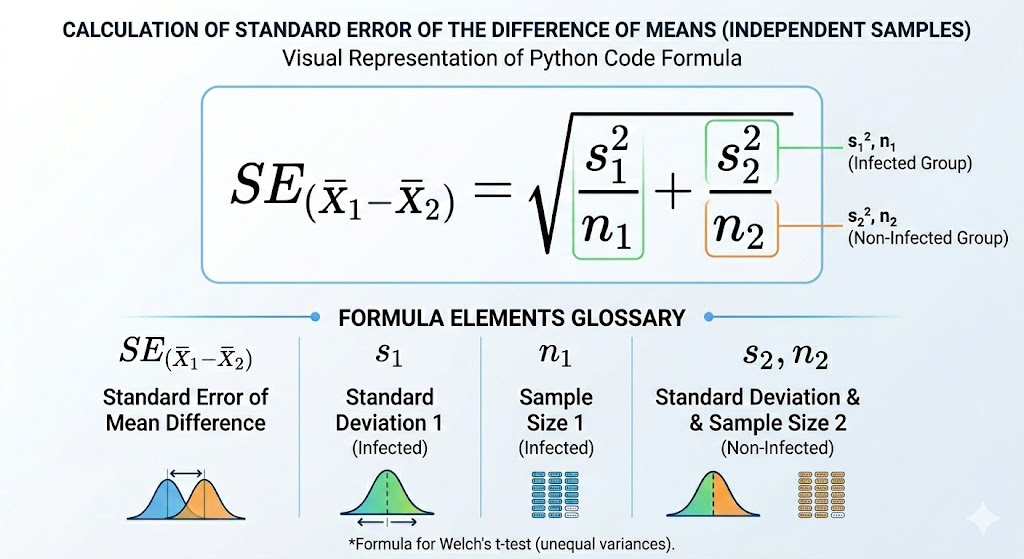

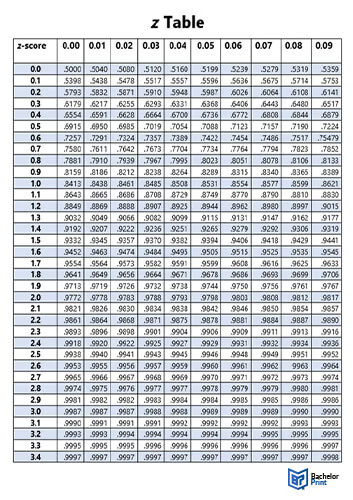

In [ ]:
mean_a = df_2[df_2['Group'] == 'Infected']['Body_Weight_kg'].mean()
mean_b = df_2[df_2['Group'] == 'Non-Infected']['Body_Weight_kg'].mean()
mean_diff = mean_a - mean_b
std_value_a = df_2[df_2['Group'] == 'Infected']['Body_Weight_kg'].std()
std_value_b = df_2[df_2['Group'] == 'Non-Infected']['Body_Weight_kg'].std()
n_a = df_2[df_2['Group'] == 'Infected']['ID'].count()
n_b = df_2[df_2['Group'] == 'Non-Infected']['ID'].count()
calculate = np.sqrt(std_value_a * std_value_a / n_a + std_value_b * std_value_b / n_b)
calculate

# --- Z critical value (95% Confidence Interval) ---
# Step 1: Define confidence level
# 95% confidence → alpha = 0.05
# Step 2: Split alpha into two tails
# alpha / 2 = 0.025
# Step 3: Find cumulative probability
# 1 - 0.025 = 0.975
# Step 4: Look up Z value in Z-table
# Z(0.975) = 1.9 + 0.06 = 1.96

z_critical = 1.9 + 0.06

confidence_low = mean_diff - calculate * z_critical
confidence_low

confidence_high = mean_diff + calculate * z_critical
confidence_high

print(f'Low: {confidence_low}, High: {confidence_high}')

confidence_high_abs = confidence_high * -1
confidence_LOW_abs = confidence_low * -1

print(f'This means that, with 95% confidence, infected survivors weigh on average between {confidence_high_abs} kg and {confidence_LOW_abs} kg less than non-infected survivors.')

Low: -6.70350174427946, High: -4.352498255720551
This means that, with 95% confidence, infected survivors weigh on average between 4.352498255720551 kg and 6.70350174427946 kg less than non-infected survivors.


# **Confidence interval for difference of two means; independent samples, variances unknown but assumed to be equal**

In [ ]:
import pandas as pd

data = {
    # 15 observações (RE2)
    "RE2_BossFight_Duration_Minutes": [
        6.4, 6.9, 5.8, 6.1, 7.0,
        6.6, 7.2, 6.3, 5.9, 6.8,
        6.0, 7.1, 6.5, 5.7, 6.7
    ],
    # 10 observações (RE7)
    "RE7_BossFight_Duration_Minutes": [
        9.2, 8.6, 10.1, 9.5, 8.9,
        9.8, 10.4, 9.0, 8.7, 9.6
    ]
}

# Preenche com None para igualar o tamanho das colunas no DataFrame
max_len = max(len(data["RE2_BossFight_Duration_Minutes"]), len(data["RE7_BossFight_Duration_Minutes"]))
data["RE2_BossFight_Duration_Minutes"] += [None] * (max_len - len(data["RE2_BossFight_Duration_Minutes"]))
data["RE7_BossFight_Duration_Minutes"] += [None] * (max_len - len(data["RE7_BossFight_Duration_Minutes"]))

df_3 = pd.DataFrame(data)
print(df_3)

    RE2_BossFight_Duration_Minutes  RE7_BossFight_Duration_Minutes
0                              6.4                             9.2
1                              6.9                             8.6
2                              5.8                            10.1
3                              6.1                             9.5
4                              7.0                             8.9
5                              6.6                             9.8
6                              7.2                            10.4
7                              6.3                             9.0
8                              5.9                             8.7
9                              6.8                             9.6
10                             6.0                             NaN
11                             7.1                             NaN
12                             6.5                             NaN
13                             5.7                            

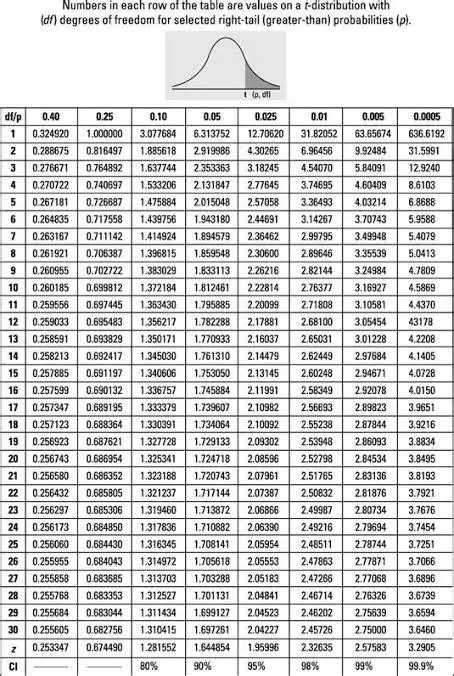

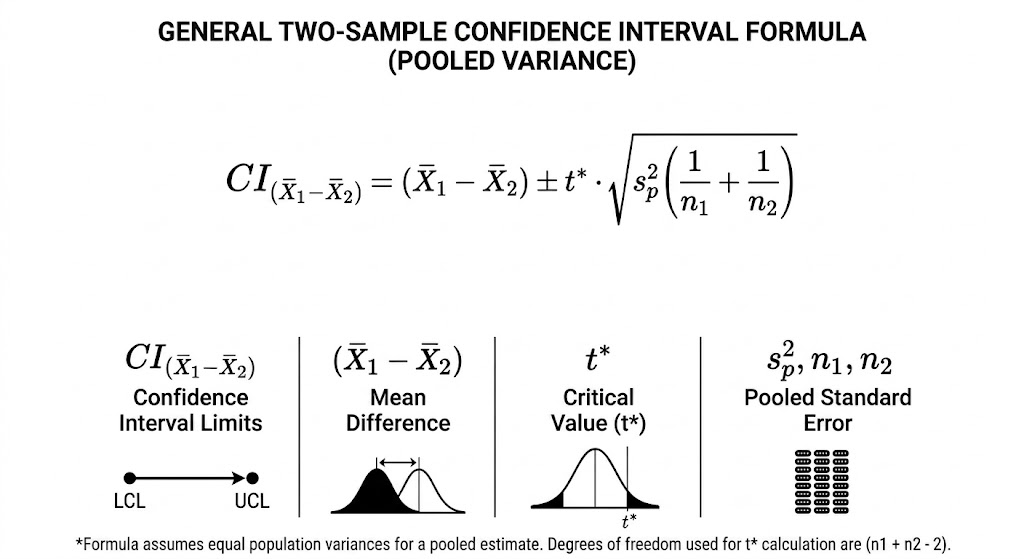

In [ ]:
RE2_mean = df_3[df_3['RE2_BossFight_Duration_Minutes'] != 'NaN']['RE2_BossFight_Duration_Minutes'].mean()
RE7_mean = df_3[df_3['RE7_BossFight_Duration_Minutes'] != 'NaN']['RE7_BossFight_Duration_Minutes'].mean()
RE2_size = df_3[df_3['RE2_BossFight_Duration_Minutes'] != 'NaN']['RE2_BossFight_Duration_Minutes'].count()
RE7_size = df_3[df_3['RE7_BossFight_Duration_Minutes'] != 'NaN']['RE7_BossFight_Duration_Minutes'].count()
RE2_std = df_3[df_3['RE2_BossFight_Duration_Minutes'] != 'NaN']['RE2_BossFight_Duration_Minutes'].std()
RE7_std = df_3[df_3['RE7_BossFight_Duration_Minutes'] != 'NaN']['RE7_BossFight_Duration_Minutes'].std()
Pooled_variance = np.sqrt(RE2_std ** 2 / RE2_size + RE7_std ** 2 / RE7_size)
Pooled_std = np.sqrt(Pooled_variance)

# 90% 23 t-> 1.713
ci_low = (RE7_mean - RE2_mean) - 1.713 * np.sqrt((Pooled_variance / RE2_size) + (Pooled_variance/ RE7_size))
ci_high = (RE7_mean - RE2_mean) + 1.713 * np.sqrt((Pooled_variance / RE2_size) + (Pooled_variance/ RE7_size))

print(f'Low: {ci_low},High: {ci_high}')

Low: 2.5789449919820133,High: 3.247721674684651
